Fitted coefficients: [0.08737302 0.42436264]


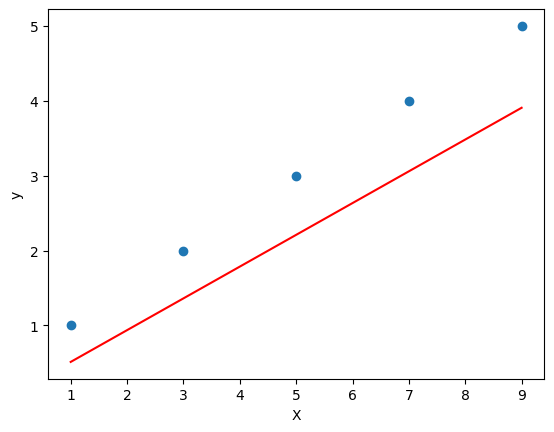

In [ ]:
#Implementing linear regression from scratch...

import numpy as np
import matplotlib.pyplot as plt

def linear_regression(X, y, learning_rate=0.01, num_iterations=1000):
    m, n = X.shape
    theta = np.zeros(n)

    for _ in range(num_iterations):
        y_pred = np.dot(X, theta)
        error = y_pred - y
        gradient = np.dot(X.T, error) / m
        theta -= learning_rate * gradient

    return theta

# Example usage
X = np.array([[1, 2], [3, 4], [5, 6], [7, 8], [9, 10]])
y = np.array([1, 2, 3, 4, 5])

theta = linear_regression(X, y)
print("Fitted coefficients:", theta)

#Plotting the plotted data

plt.scatter(X[:, 0], y)
plt.plot(X[:, 0], theta[0] + theta[1] * X[:, 0], 'r')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

2.993373349339736 5.768979591836725
1.4308552220888375 1.1961836071811207


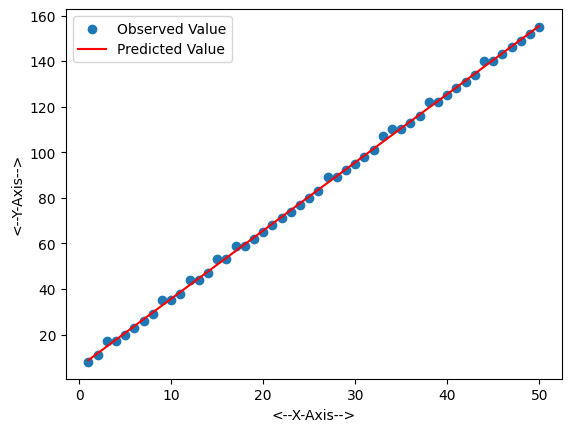

In [ ]:
#Implementing linear regression using Ordinary Least Squares method

import numpy as np 
import matplotlib.pyplot as plt

def compute_coefficient(x, y):
    n = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)

    numerator, denominator = 0, 0
    for i in range(n):
        numerator += (x[i] - x_mean) * (y[i] - y_mean) #Calculating covariance
        denominator += (x[i] - x_mean) ** 2 #Calculating variance
    
    slope = numerator / denominator
    intercept = y_mean - slope * x_mean
    return slope, intercept

def predict(x, w1, w0):
    return w1 * x + w0

x = np.arange(1, 51)
y = x*3+5
w1, w0 = compute_coefficient(x, y)


# Add some random error to the array
y[np.random.randint(0, len(y), size=10)] += np.random.randint(-5, 5)

w1, w0 = compute_coefficient(x, y)
y_hat = predict(x,w1,w0)
# display the value of predicted coefficients
print(w1,w0)

def evaluate_ols(y,y_hat):
    mse = np.mean((y - y_hat) ** 2)
    return mse, np.sqrt(mse)

mse, rmse = evaluate_ols(y,y_hat)
print(mse,rmse)

plt.scatter(x, y, label='Observed Value')
plt.plot(x, y_hat, label='Predicted Value', color='red')
plt.xlabel('<--X-Axis-->')
plt.ylabel('<--Y-Axis-->')
plt.legend()
plt.show()

In [ ]:
#Multiple Linear Regression...

#Reference: beta = (X^T.X)^-1.X^T.y

def multiple_linear_regression(X, y):
    beta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
    return beta

In [2]:
#Assignment 2 practice: Implementing linear regression using California Housing dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load the in-built California Housing dataset:

df = pd.read_csv('https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv')

#Drop all nan rows:
df = df.dropna()
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Split the data into training and testing sets:

feature_drop = ['median_house_value', 'longitude', 'latitude', 'ocean_proximity', 'housing_median_age']
X = df.drop(feature_drop, axis=1)

y = df['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

[-2.91231203e+01  1.16426039e+02 -3.23185817e+01  1.37308733e+02
  5.06548023e+04]
14416    183563.042665
16383    194629.820275
7731     189180.351663
1410     149428.136242
1335     247353.470505
             ...      
8291     253364.087096
6274     165706.573724
2997     144215.764834
13440    176864.025222
14797    167178.966923
Length: 4087, dtype: float64
MSE: 6392549334.137793
RMSE: 79953.41977762923
R^2: 0.5325437056993485


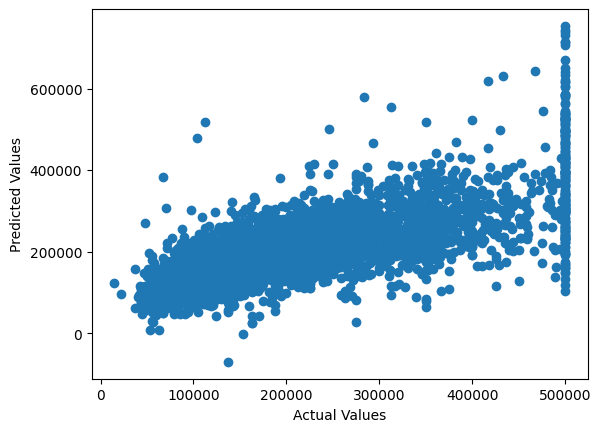

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt

def multiple_linear_regression(X, y):
    beta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y) #beta = (X^T.X)^-1.X^T.y
    return beta

#send X_train and y_train to multiple_linear_regression function
beta = multiple_linear_regression(X_train, y_train)
print(beta)

#send X_test and beta to predict function
y_pred = predictions = X_test.dot(beta)
print(y_pred)

#metrics to test the prediction
ss_residuals = sum((y_test - y_pred) ** 2)
mse = ss_residuals / len(y_test)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

#Finding the R^2 value
y_mean = np.mean(y_test)
ss_total = sum((y_test - y_mean) ** 2)
r_squared = 1 - (ss_residuals / ss_total)
print("R^2:", r_squared)

#Plotting the predicted and actual values
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

In [12]:
#Practicing Naive Bayes classifier implementation from scratch:

#Step 1, inputtng the PlayTennis table:
'''
Outlook	Temperature	Humidity	Wind	Play
Sunny	Hot	High	Weak	No
Sunny	Hot	High	Strong	No
Overcast	Hot	High	Weak	Yes
Rain	Mild	High	Weak	Yes
Rain	Cool	Normal	Weak	Yes
Rain	Cool	Normal	Strong	No
Overcast	Cool	Normal	Strong	Yes
Sunny	Mild	High	Weak	No
Sunny	Cool	Normal	Weak	Yes
Rain	Mild	Normal	Weak	Yes
Sunny	Mild	Normal	Strong	Yes
Overcast	Mild	High	Strong	Yes
Overcast	Hot	Normal	Weak	Yes
Rain	Mild	High	Strong	No

'''

#Creating a multidimensional np array of the above table
import numpy as np
import pandas as pd

data = [
    ['Sunny', 'Hot', 'High', 'Weak', 'No'],
    ['Sunny', 'Hot', 'High', 'Strong', 'No'],
    ['Overcast', 'Hot', 'High', 'Weak', 'Yes'],
    ['Rain', 'Mild', 'High', 'Weak', 'Yes'],
    ['Rain', 'Cool', 'Normal', 'Weak', 'Yes'],
    ['Rain', 'Cool', 'Normal', 'Strong', 'No'],
    ['Overcast', 'Cool', 'Normal', 'Strong', 'Yes'],
    ['Sunny', 'Mild', 'High', 'Weak', 'No'],
    ['Sunny', 'Cool', 'Normal', 'Weak', 'Yes'],
    ['Rain', 'Mild', 'Normal', 'Weak', 'Yes'],
    ['Sunny', 'Mild', 'Normal', 'Strong', 'Yes'],
    ['Overcast', 'Mild', 'High', 'Strong', 'Yes'],
    ['Overcast', 'Hot', 'Normal', 'Weak', 'Yes'],
    ['Rain', 'Mild', 'High', 'Strong', 'No']
]

data = np.array(data)

#Fitting the above data into a dataframe with column labels 'Outlook', 'Temperature', 'Humidity', 'Wind', 'Play'
df = pd.DataFrame(data, columns=['Outlook', 'Temperature', 'Humidity', 'Wind', 'Play'])

#Finding P(yes) or P(no) for each final PlayTennis output (Class Probability)
def calculate_class_probability(class_label: str):
    count = np.sum(data[:, 4] == class_label)
    total = len(data)
    return count / total

#Finding P(feature|yes) or P(feature|no) for each feature (Conditional Probability)
def calculate_conditional_probability(col_index, value, class_label):
    class_mask = (data[:, 4] == class_label)
    feature_match = (data[:, col_index] == value)
    count = np.sum(class_mask & feature_match)
    total = np.sum(class_mask)
    return count / total

#New input: Outlook: 'Sunny', Temperature: 'Hot', Humidity: 'Normal', Wind: 'Strong'
features = ['Outlook', 'Temperature', 'Humidity', 'Wind']
values = ['Sunny', 'Hot', 'Normal', 'Strong']

#Calculating P(yes) and P(no)
P_yes = calculate_class_probability('Yes')
P_no = calculate_class_probability('No')

#Calculating P(feature|yes) and P(feature|no)
P_feature_given_yes = [calculate_conditional_probability(i, values[i], 'Yes') for i in range(len(features))]
P_feature_given_no = [calculate_conditional_probability(i, values[i], 'No') for i in range(len(features))]

#Calculating P(yes|features) and P(no|features) (Posterior Probability)
P_yes_given_features = P_yes * np.prod(P_feature_given_yes)
P_no_given_features = P_no * np.prod(P_feature_given_no)

#Normalizing the posterior probabilities
P_yes_given_features /= (P_yes_given_features + P_no_given_features)
P_no_given_features /= (P_yes_given_features + P_no_given_features)

#Displaying the calculated probabilities
print("P(yes):", P_yes)
print("P(no):", P_no)
print("P(yes|features):", P_yes_given_features)
print("P(no|features):", P_no_given_features)

#Calculating the predicted class
if P_yes_given_features > P_no_given_features:
    predicted_class = 'Yes'
else:
    predicted_class = 'No'
print("Predicted class:", predicted_class)

P(yes): 0.6428571428571429
P(no): 0.35714285714285715
P(yes|features): 0.4068348250610252
P(no|features): 0.02465885353385604
Predicted class: Yes


In [1]:
#Sample dataset creation for ML Lab Exam:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

# Generate 50 samples
n = 50
rh = np.random.uniform(40, 90, n)  # Relative Humidity
temp = 15 + 0.25 * rh + np.random.normal(0, 1, n)  # Temperature correlated with RH

# True relationship: AOD = 0.01 + 0.003*RH + 0.005*Temp + noise
aod = 0.01 + 0.003 * rh + 0.005 * temp + np.random.normal(0, 0.01, n)

# Create DataFrame
df = pd.DataFrame({
    'RH': np.round(rh, 1),
    'Temp': np.round(temp, 1),
    'AOD': np.round(aod, 3)
})

# Save to CSV
df.to_csv('atmospheric_data.csv', index=False)
print("Dataset 'atmospheric_data.csv' created successfully.")

Dataset 'atmospheric_data.csv' created successfully.


In [ ]:
import numpy as np
import pandas as pd

atm_df = pd.read_csv('atmospheric_data.csv')

#Augment the dataset with a set of 1s for Beta0
atm_df['Augment'] = [1] * len(atm_df)

print(atm_df.head())

features = atm_df.drop('AOD', axis=1)
target = atm_df['AOD']

#print dimensions of feature and target:
print(features.shape, target.shape)

print(features.head())
print(target.head())

#Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

def multiple_regression(X, y): #X = Feature vector, y = Target vector
    beta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y) #beta = (X^T.X)^-1.X^T.y
    return beta

beta = multiple_regression(X_train, y_train)
print(beta)

#print regression equation in form AOD = \beta_0 + \beta_1(RH) + \beta_2(Temp)$

print(f"AOD = {beta[0]:.5f} + {beta[1]:.5f}*RH + {beta[2]:.5f}*Temp")

y_pred = X_test.dot(beta) #X.beta = y_pred
print(y_pred)

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.5f}")

     RH  Temp    AOD  Augment
0  58.7  30.4  0.339        1
1  87.5  37.1  0.468        1
2  76.6  34.0  0.403        1
3  69.9  32.2  0.377        1
4  47.8  25.5  0.277        1
(50, 3) (50,)
     RH  Temp  Augment
0  58.7  30.4        1
1  87.5  37.1        1
2  76.6  34.0        1
3  69.9  32.2        1
4  47.8  25.5        1
0    0.339
1    0.468
2    0.403
3    0.377
4    0.277
Name: AOD, dtype: float64
(40, 3) (40,)
(10, 3) (10,)
[0.00362808 0.00302791 0.02956794]
AOD = 0.00363 + 0.00303*RH + 0.02957*Temp
13    0.298839
39    0.340804
30    0.384906
45    0.394096
17    0.364520
48    0.368511
26    0.293937
25    0.426885
32    0.264784
19    0.317287
dtype: float64
Mean Squared Error: 0.00008


Generated 300 samples across 3 classes in 'land_cover_data.csv'.


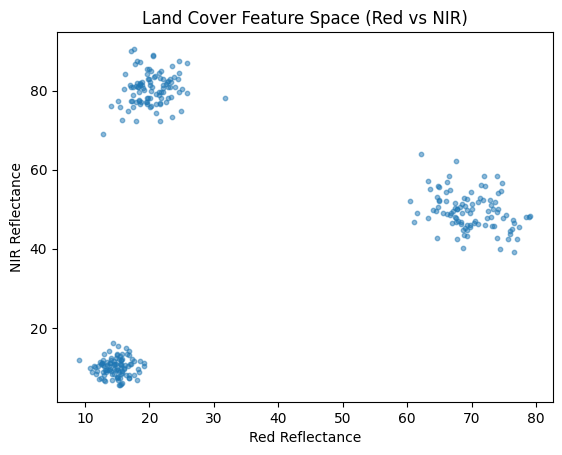

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for reproducible exam results
np.random.seed(42)

def generate_cluster(mean, cov, n_samples, label):
    data = np.random.multivariate_normal(mean, cov, n_samples)
    return pd.DataFrame(data, columns=['Red_Reflectance', 'NIR_Reflectance'])

# Define three clusters (Red, NIR)
# Cluster 1: Water (Low Red, Low NIR)
water = generate_cluster([15, 10], [[5, 0], [0, 5]], 100, 'Water')

# Cluster 2: Vegetation (Low Red, High NIR)
veg = generate_cluster([20, 80], [[10, 2], [2, 15]], 100, 'Vegetation')

# Cluster 3: Urban/Soil (High Red, Medium NIR)
urban = generate_cluster([70, 50], [[20, -5], [-5, 20]], 100, 'Urban')

# Combine and shuffle
df = pd.concat([water, veg, urban]).sample(frac=1).reset_index(drop=True)

# Save to CSV
df.to_csv('land_cover_data.csv', index=False)

print("Generated 300 samples across 3 classes in 'land_cover_data.csv'.")

# Quick visual check for the instructor
plt.scatter(df['Red_Reflectance'], df['NIR_Reflectance'], s=10, alpha=0.5)
plt.title("Land Cover Feature Space (Red vs NIR)")
plt.xlabel("Red Reflectance")
plt.ylabel("NIR Reflectance")
plt.show()

    Red_Reflectance  NIR_Reflectance  Cluster
0         12.336164        11.468098      2.0
1         13.782723        10.248030      2.0
2         70.983539        51.834158      0.0
3         20.042306        75.863572      1.0
4         15.130159         7.444241      2.0
5         14.123220         6.727481      2.0
6         64.404102        49.435979      0.0
7         13.654543        14.141820      2.0
8         13.192153         8.878037      2.0
9         17.173888        77.465155      1.0
10        17.305385        12.082406      2.0
11        13.656931         9.347753      2.0
12        61.012165        46.876948      0.0
13        67.665922        50.059453      0.0
14        66.775278        49.125093      0.0
15        16.768801         7.966548      2.0
16        19.171999        11.059523      2.0
17        15.029073        13.250201      2.0
18        13.479418        10.519335      2.0
19        24.452803        82.986031      1.0
20        71.706566        52.4089

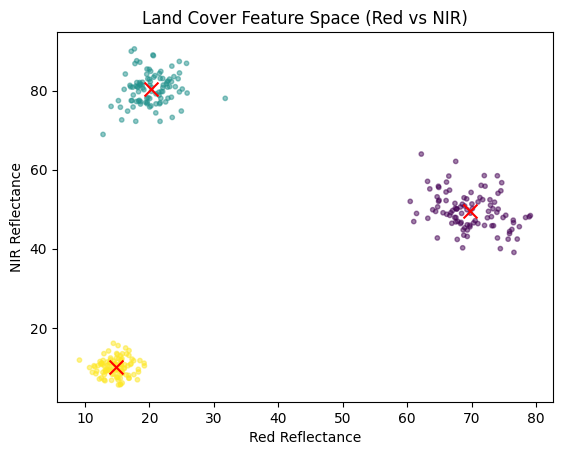

In [12]:
#Practicing K-Means implementation

import numpy as np
import pandas as pd

df = pd.read_csv('land_cover_data.csv')
row, col = df.shape

def init_centroids(k, data):
    # Select k random row indices
    indices = np.random.choice(row, k, replace=False) #replace=False ensures that no index is selected twice
    # Use .iloc to get the actual data values for those indices
    return data.iloc[indices].values

def euclid_dist(point, centroids):
    # Sum along axis 1 to get a distance for each centroid
    return np.sqrt(np.sum((point - centroids)**2, axis=1))

def assign_clusters(data, centroids):
    clusters = np.zeros(row)
    # Convert dataframe to numpy for faster indexing if needed
    data_np = data.values 
    for i in range(row):
        # Now returns 3 distances because of axis=1 in euclid_dist
        distances = euclid_dist(data_np[i], centroids)
        clusters[i] = np.argmin(distances) #argmin returns index of the shortest distance in distances
    return clusters

def update_clusters(data, clusters, k):
    new_centroids = np.zeros_like(centroids) 
    for i in range(k):
        points_in_cluster = data[clusters == i]
        if len(points_in_cluster) > 0:
            new_centroids[i] = np.mean(points_in_cluster, axis=0)
        else:
            # If a cluster is empty, keep the old centroid or re-initialize
            pass 
    return new_centroids

centroids = init_centroids(3, df)
max_iter = 1000

for i in range(max_iter):
    clusters = assign_clusters(df, centroids)
    new_centroids = update_clusters(df, clusters, 3)

    if np.all(centroids == new_centroids):
        break

    centroids = new_centroids

#Add the centroids to the dataframe after classification
df['Cluster'] = clusters

print(df.head(50))

#Plot the clusters color-coded on a scatterplot
import matplotlib.pyplot as plt
plt.scatter(df['Red_Reflectance'], df['NIR_Reflectance'], s=10, alpha=0.5, c=df['Cluster'])
plt.title("Land Cover Feature Space (Red vs NIR)")
plt.xlabel("Red Reflectance")
plt.ylabel("NIR Reflectance")
#Plot the centroids too
plt.scatter(centroids[:, 0], centroids[:, 1], s=100, marker='x', c='red')
plt.show()


Generated 100 samples in 'flood_data.csv'.


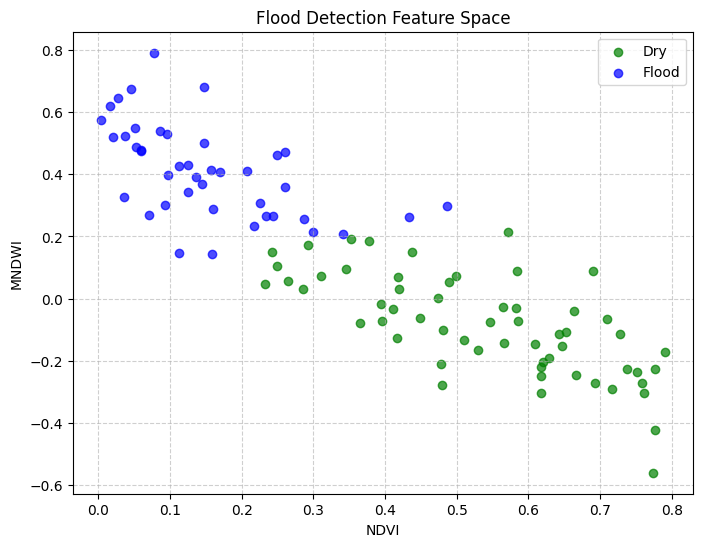

In [3]:
#Code generation for question
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

n_samples = 100

# Generate NDVI: Generally higher for dry land/veg (0.2 to 0.8), lower for water (0.0 to 0.2)
ndvi = np.random.uniform(0.0, 0.8, n_samples)

# Generate MNDWI: Generally higher for water (0.1 to 0.7), lower for dry land (-0.5 to 0.1)
# We make MNDWI somewhat inversely correlated with NDVI for realism
mndwi = 0.5 - ndvi + np.random.normal(0, 0.15, n_samples)

# Define the True Label (Binary)
# Logic: If (2 * MNDWI - NDVI) > 0.1, it's likely flooded
z = 2.5 * mndwi - 1.2 * ndvi - 0.1
prob = 1 / (1 + np.exp(-z))
labels = (prob > 0.5).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'NDVI': np.round(ndvi, 3),
    'MNDWI': np.round(mndwi, 3),
    'Label': labels
})

# Save to CSV
df.to_csv('flood_data.csv', index=False)
print("Generated 100 samples in 'flood_data.csv'.")

# Instructor Visual Check
plt.figure(figsize=(8, 6))
plt.scatter(df[df['Label'] == 0]['NDVI'], df[df['Label'] == 0]['MNDWI'], color='green', label='Dry', alpha=0.7)
plt.scatter(df[df['Label'] == 1]['NDVI'], df[df['Label'] == 1]['MNDWI'], color='blue', label='Flood', alpha=0.7)
plt.xlabel('NDVI')
plt.ylabel('MNDWI')
plt.title('Flood Detection Feature Space')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
#Implementing logistic regression classifier from scratch...
import numpy as np
import pandas as pd

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def bce(y_true, y_pred):
    
    y1 = (y_true)*np.log(y_pred)
    y2 = (1-y_true)*np.log(1-y_pred)

    return -1 * np.mean(y1+y2)

def bce_prime(y_true, y_pred):
    return (y_pred - y_true) / (y_pred * (1 - y_pred))


def gradient_descent(X, y, learning_rate, num_iterations):
    row, col = X.shape

    X = np.column_stack((np.ones(row), X)) #Pad ones to the feature matrix
    beta = np.zeros(col+1) #Initialize the weight vector, accounting for the padded ones in prev line
    
    for _ in range(num_iterations):
        y_pred = sigmoid(X.dot(beta)) #y_pred = X.beta
        gradient = X.T.dot(y_pred - y) / len(y)
        beta -= learning_rate * gradient
    return beta

learning_rate = 0.01
num_iterations = 1000

df = pd.read_csv('flood_data.csv')
X, y = df[['NDVI', 'MNDWI']].values, df['Label'].values

# 1. Train the model
beta = gradient_descent(X, y, learning_rate, num_iterations)
print("Gradient Descent Beta Values: ", beta)

# 2. Prepare X for final verification (Add the intercept column)
X_test = np.column_stack((np.ones(X.shape[0]), X))

# 3. Calculate final predictions and cost
y_final_pred = sigmoid(X_test.dot(beta))
cost = bce(y, y_final_pred)

print("Cost Function Value: ", cost)

# 4. Accuracy Check (Simple Logic)
predictions = (y_final_pred >= 0.5).astype(int)
accuracy = np.mean(predictions == y)
print(f"Model Accuracy: {accuracy * 100}%")

Gradient Descent Beta Values:  [-0.16810254 -0.86532199  1.00921542]
Cost Function Value:  0.5052016409505329
Model Accuracy: 87.0%


In [ ]:
#Linear Perceptron practice
import pandas as pd
import numpy as np

df = pd.read_csv('flood_data.csv')
X, y = df[['NDVI', 'MNDWI']].values, df['Label'].values

w = np.array([0.5, 0.5]) # Use numpy array for weights
b = 0.1
epochs = 200
learning_rate = 0.01 # Define your learning rate

def activation_func_sigmoid(x):
    return 1 / (1 + np.exp(-x))

for _ in range(epochs):
    # 1. Forward Pass: Dot product + bias
    z = X.dot(w) + b
    y_pred = activation_func_sigmoid(z)
    
    # 2. Error and Derivative
    # (y - y_pred) is the error
    # y_pred * (1 - y_pred) is the derivative of sigmoid
    error_term = (y - y_pred) * y_pred * (1 - y_pred)
    
    # 3. Update Weights (Averaging over all samples)
    for i in range(len(w)):
        # Calculate the average gradient for this weight
        gradient = np.mean(error_term * X[:, i])
        w[i] = w[i] + learning_rate * gradient
        
    # 4. Update Bias
    b = b + learning_rate * np.mean(error_term)

print(f"Final Weights: {w}")
print(f"Final Bias: {b}")

Final Weights: [0.42590702 0.54747845]
Final Bias: 0.023360139010024237


In [8]:
#Implementing one round of decision tree...
import numpy as np
import pandas as pd

data = [
    ['Sunny', 'Hot', 'High', 'Weak', 'No'],
    ['Sunny', 'Hot', 'High', 'Strong', 'No'],
    ['Overcast', 'Hot', 'High', 'Weak', 'Yes'],
    ['Rain', 'Mild', 'High', 'Weak', 'Yes'],
    ['Rain', 'Cool', 'Normal', 'Weak', 'Yes'],
    ['Rain', 'Cool', 'Normal', 'Strong', 'No'],
    ['Overcast', 'Cool', 'Normal', 'Strong', 'Yes'],
    ['Sunny', 'Mild', 'High', 'Weak', 'No'],
    ['Sunny', 'Cool', 'Normal', 'Weak', 'Yes'],
    ['Rain', 'Mild', 'Normal', 'Weak', 'Yes'],
    ['Sunny', 'Mild', 'Normal', 'Strong', 'Yes'],
    ['Overcast', 'Mild', 'High', 'Strong', 'Yes'],
    ['Overcast', 'Hot', 'Normal', 'Weak', 'Yes'],
    ['Rain', 'Mild', 'High', 'Strong', 'No']
]

data = np.array(data)
columns=['Outlook', 'Temperature', 'Humidity', 'Wind', 'Play']
#Fitting the above data into a dataframe with column labels 'Outlook', 'Temperature', 'Humidity', 'Wind', 'Play'
df = pd.DataFrame(data, columns=columns)

# Step 1: Calculate overall entropy
def calculate_entropy(target_col):
    unique_vals, counts = np.unique(target_col, return_counts=True)
    probabilities = counts / len(target_col)
    # Filter out 0 probabilities to avoid log2(0) error
    probabilities = probabilities[probabilities > 0]
    return -np.sum(probabilities * np.log2(probabilities))

total_entropy = calculate_entropy(df['Play'])
print(f"Total System Entropy (PlayTennis): {total_entropy:.4f}\n")

# Step 2: Calculate IG for each feature
feature_columns = columns[:-1]
ig_results = {}

for col_name in feature_columns:
    unique_vals, counts = np.unique(df[col_name], return_counts=True)
    
    weighted_entropy = 0
    for i in range(len(unique_vals)):
        # Subset data where feature == unique value
        subset = df[df[col_name] == unique_vals[i]]['Play']
        feature_val_entropy = calculate_entropy(subset)
        
        # Calculate weight (proportion of samples)
        weight = counts[i] / len(df)
        weighted_entropy += weight * feature_val_entropy
    
    # Information Gain = Total Entropy - Weighted Entropy
    info_gain = total_entropy - weighted_entropy
    ig_results[col_name] = info_gain
    print(f"Attribute: {col_name:12} | Weighted Entropy: {weighted_entropy:.4f} | IG: {info_gain:.4f}")

best_feature = max(ig_results, key=ig_results.get)
print(f"\nBest Feature to split on: {best_feature}")

Total System Entropy (PlayTennis): 0.9403

Attribute: Outlook      | Weighted Entropy: 0.6935 | IG: 0.2467
Attribute: Temperature  | Weighted Entropy: 0.9111 | IG: 0.0292
Attribute: Humidity     | Weighted Entropy: 0.7885 | IG: 0.1518
Attribute: Wind         | Weighted Entropy: 0.8922 | IG: 0.0481

Best Feature to split on: Outlook


In [1]:
#Generating data for Max Likelihood Classifier:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

def generate_spectral_class(mean, cov, n_samples, label):
    data = np.random.multivariate_normal(mean, cov, n_samples)
    df = pd.DataFrame(data, columns=['Green', 'Red', 'NIR'])
    df['Label'] = label
    return df

# 1. Water: Low reflectance in all bands, very low variance
mean_water = [10, 8, 5]
cov_water = [[2, 0.5, 0.2], [0.5, 2, 0.3], [0.2, 0.3, 1]]
water_df = generate_spectral_class(mean_water, cov_water, 100, 'Water')

# 2. Vegetation: Low Red, High NIR (The "Red Edge" effect)
mean_veg = [20, 15, 80]
cov_veg = [[10, 5, 2], [5, 10, -2], [2, -2, 40]]
veg_df = generate_spectral_class(mean_veg, cov_veg, 100, 'Vegetation')

# 3. Urban: High reflectance across all bands, high variance
mean_urban = [60, 65, 55]
cov_urban = [[30, 20, 15], [20, 35, 10], [15, 10, 25]]
urban_df = generate_spectral_class(mean_urban, cov_urban, 100, 'Urban')

# Combine and shuffle
dataset = pd.concat([water_df, veg_df, urban_df]).sample(frac=1).reset_index(drop=True)

# Save to CSV
dataset.to_csv('spectral_data.csv', index=False)
print("Dataset 'spectral_data.csv' created successfully.")

Dataset 'spectral_data.csv' created successfully.


In [22]:
#Implementation of the Max Likelihood Classifier:
import numpy as np
import pandas as pd

#Step 1: Inputting the dataset:
spec_df = pd.read_csv('spectral_data.csv')

X = spec_df.drop('Label', axis=1)
y = spec_df['Label']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Training (Calculate once)
mean_vectors = {}
inv_cov_matrices = {}
det_cov_logs = {}

for label in np.unique(y_train):
    subset = X_train[y_train == label]
    
    mu = subset.mean().values
    sigma = subset.cov().values
    
    mean_vectors[label] = mu
    inv_cov_matrices[label] = np.linalg.inv(sigma) # Pre-calculate
    det_cov_logs[label] = np.log(np.linalg.det(sigma)) # Pre-calculate

# Optimized Discriminant Function
def g_i(x, label):
    mu = mean_vectors[label]
    inv_sigma = inv_cov_matrices[label]
    ln_det_sigma = det_cov_logs[label]
    
    diff = x - mu
    # Mahalanobis Distance term
    mahalanobis = np.dot(diff.T, np.dot(inv_sigma, diff))
    
    return -0.5 * ln_det_sigma - 0.5 * mahalanobis

#Testing phase:
def predict(x):
    probabilities = {}
    for label in np.unique(y_train):
        probabilities[label] = g_i(x, label)
    print(probabilities)
    predicted_label = max(probabilities, key=probabilities.get)
    return predicted_label

#Testing the model:
y_pred = []
print (X.columns)
for x in X_test.values:
    print(f"Input: {x}")
    predicted_label = predict(x)
    #Print predicted values
    
    print(f"Predicted Label: {predicted_label}")
    y_pred.append(predicted_label)

accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy:.4f}")

Index(['Green', 'Red', 'NIR'], dtype='object')
Input: [15.66554795 15.1917484  78.96235496]
{'Urban': np.float64(-100.29237848356044), 'Vegetation': np.float64(-5.479960810910052), 'Water': np.float64(-2131.6509190987745)}
Predicted Label: Vegetation
Input: [58.46248264 56.33561078 50.9459397 ]
{'Urban': np.float64(-6.216305445298064), 'Vegetation': np.float64(-113.02689244358372), 'Water': np.float64(-1875.4026891160224)}
Predicted Label: Urban
Input: [63.71579153 63.10475749 55.7894497 ]
{'Urban': np.float64(-5.244942777278114), 'Vegetation': np.float64(-145.5334839699515), 'Water': np.float64(-2341.8373650734684)}
Predicted Label: Urban
Input: [10.56692623  9.56010173  5.51778226]
{'Urban': np.float64(-86.17607572132863), 'Vegetation': np.float64(-91.0970030664174), 'Water': np.float64(-1.6461302060205005)}
Predicted Label: Water
Input: [10.10423029  9.02192147  3.81318055]
{'Urban': np.float64(-89.51172432392279), 'Vegetation': np.float64(-95.83648312248765), 'Water': np.float64(-1

c:\Users\Sohum Chatterjee\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


              precision    recall  f1-score   support

           0       0.33      0.33      0.33      3352
           1       0.32      0.32      0.32      3360
           2       0.34      0.33      0.34      3353

    accuracy                           0.33     10065
   macro avg       0.33      0.33      0.33     10065
weighted avg       0.33      0.33      0.33     10065



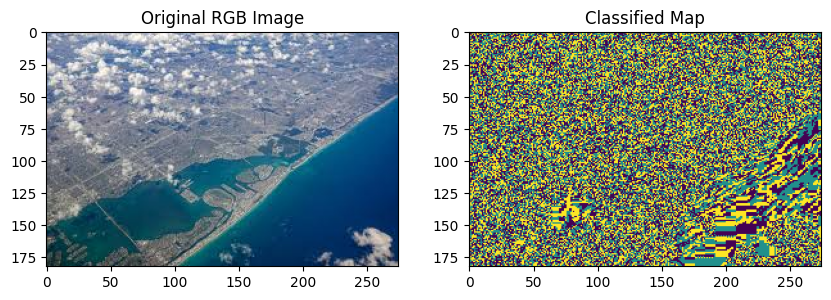

In [1]:
#Classifying a satellite image:
import numpy as np
import rasterio
import matplotlib.pyplot as plt

raster_path = r'C:\Users\Sohum Chatterjee\Downloads\Large Datasets\Earth Explorer Datasets\image\satellite_image.TIF'

# Step 1: Load the image
with rasterio.open(raster_path) as src:
    image = src.read()
    X = image.transpose(1, 2, 0).reshape(-1, src.count) # Reshape to (n_samples, n_features)
    y = np.random.choice([0, 1, 2], size=X.shape[0]) # Generate random labels

mask = np.all(np.isfinite(X), axis=1)
X = X[mask]
y = y[mask]

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
report = classification_report(y_test, y_pred)
print(report)

if 'src' in locals():
    classified = clf.predict(X).reshape(src.height, src.width)
    original_image_display = image.transpose(1, 2, 0)
else:
    classified = clf.predict(X).reshape(100, 100)
    original_image_display = image

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(original_image_display)
ax[0].set_title("Original RGB Image")
ax[1].imshow(classified, cmap='viridis')
ax[1].set_title("Classified Map")
plt.show()

In [3]:
#Opening a satellite image:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

raster_path = r'C:\Users\Sohum Chatterjee\Downloads\Large Datasets\Earth Explorer Datasets\LCAI_image_raster.TIF'
with rasterio.open(raster_path) as src:
    image = src.read().transpose(1, 2, 0)

mask_path = r'C:\Users\Sohum Chatterjee\Downloads\Large Datasets\Earth Explorer Datasets\LCAI_mask_raster.TIF'
with rasterio.open(mask_path) as mask_src:
    mask = mask_src.read().transpose(1, 2, 0)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image)
ax[0].set_title("Original RGB Image")
ax[1].imshow(mask, cmap='viridis')
ax[1].set_title("Mask")
plt.show()

KeyboardInterrupt: 

              precision    recall  f1-score   support

           0       0.54      0.65      0.59     40934
           1       0.01      0.29      0.02       126
           2       0.89      0.66      0.76    135952
           3       0.62      0.84      0.71     21694
           4       0.04      0.52      0.08      1294

    accuracy                           0.68    200000
   macro avg       0.42      0.59      0.43    200000
weighted avg       0.78      0.68      0.71    200000



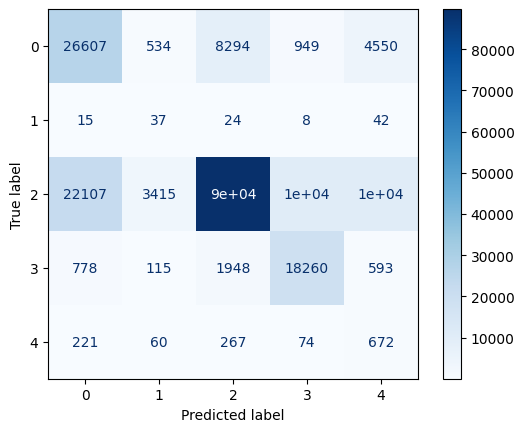

In [5]:

#Opening a satellite image:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

raster_path = r'C:\Users\Sohum Chatterjee\Downloads\Large Datasets\Earth Explorer Datasets\LCAI_image_raster.TIF'
mask_path = r'C:\Users\Sohum Chatterjee\Downloads\Large Datasets\Earth Explorer Datasets\LCAI_mask_raster.TIF'

# --- STEP 1: Load and Reshape ---
with rasterio.open(raster_path) as src:
    # Use float32 to save 50% RAM immediately compared to float64
    image = src.read().transpose(1, 2, 0).reshape(-1, 3).astype('float32')

with rasterio.open(mask_path) as mask_src:
    mask = mask_src.read(1).flatten() # Read only band 1 to keep it 1D

# --- STEP 2: Subsample BEFORE splitting ---
# We pick our samples from the raw pool immediately to free up RAM later
n_total = image.shape[0]
n_samples = 1000000 
indices = np.random.choice(n_total, n_samples, replace=False)

X_small = image[indices]
y_small = mask[indices]

# OPTIONAL: Manually clear the massive arrays if you don't need the full image yet
# del image 
# import gc; gc.collect() 

# --- STEP 3: Split the SMALL dataset ---
# Now we are only splitting 1 million rows, not 87 million.
X_train, X_test, y_train, y_test = train_test_split(X_small, y_small, test_size=0.2)

# --- STEP 4: Train with Constraints ---
clf = RandomForestClassifier(
    n_estimators=50,
    max_depth=12,    # Crucial: prevents trees from becoming memory-hogs
    class_weight='balanced',
    n_jobs=-1,       # Use all 16 cores of your Ryzen 9
    random_state=42
)
clf.fit(X_train, y_train)

# --- STEP 5: Predict & Report ---
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()

              precision    recall  f1-score   support

           0       0.06      0.24      0.10     13248
           1       0.00      0.00      0.00         0
           2       0.93      0.50      0.65    186752
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0

    accuracy                           0.48    200000
   macro avg       0.20      0.15      0.15    200000
weighted avg       0.88      0.48      0.62    200000



c:\Users\Sohum Chatterjee\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sohum Chatterjee\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sohum Chatterjee\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _war

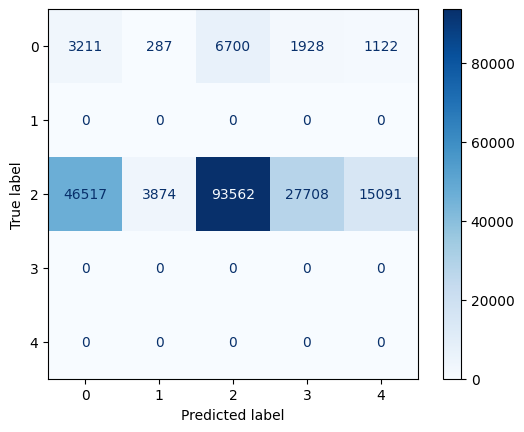

Success! 'Final_Classified_Result.tif' is ready.


In [19]:
#Patch version of a satellite classifier:
import rasterio
from rasterio.windows import Window
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import numpy as np

image_path = r'C:\Users\Sohum Chatterjee\Downloads\Large Datasets\Earth Explorer Datasets\LCAI_image_raster.TIF'
mask_path = r'C:\Users\Sohum Chatterjee\Downloads\Large Datasets\Earth Explorer Datasets\LCAI_mask_raster.TIF'

win = Window(col_off=1000, row_off=1000, width=1000, height=1000)

with rasterio.open(image_path) as src:
    patch_image = src.read(window=win).transpose(1, 2, 0).astype('float32')
    out_crs = src.crs
    out_transform = rasterio.windows.transform(win, src.transform)

with rasterio.open(mask_path) as src:
    patch_mask = src.read(1, window=win).flatten()

#Reshape for training:
X_patch = patch_image.reshape(-1, 3)
y_patch = patch_mask

X_train, X_test, y_train, y_test = train_test_split(X_patch, y_patch, test_size=0.2)

clf = RandomForestClassifier(
    n_estimators=15, 
    max_depth=12,
    n_jobs=-1,
    class_weight='balanced',
    random_state=42)
clf.fit(X_train, y_train)

prediction = clf.predict(X_patch)
classified_map = prediction.reshape(1000, 1000)

#Plot classification report:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.show()


# Update the profile for the new 1-band classified image
# 2. THE "CLEAN SLATE" DICTIONARY
# We do NOT use .update() or .copy() here. We build from scratch.
output_meta = {
    'driver': 'GTiff',
    'dtype': 'uint8',
    'nodata': 0,
    'width': 1000,
    'height': 1000,
    'count': 1,
    'crs': out_crs,
    'transform': out_transform,
    'tiled': False,      # Explicitly disable tiling to avoid StripOffset issues
    'compress': 'lzw',
    'interleave': 'band'
}

# 3. Write to a NEW filename to ensure no cache interference
with rasterio.open('Final_Classified_Result.tif', 'w', **output_meta) as dst:
    dst.write(classified_map.astype('uint8'), 1)

print("Success! 'Final_Classified_Result.tif' is ready.")

(1000, 1000)
[[2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]
 [2 2 2 ... 2 2 2]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 2 ... 0 0 0]]


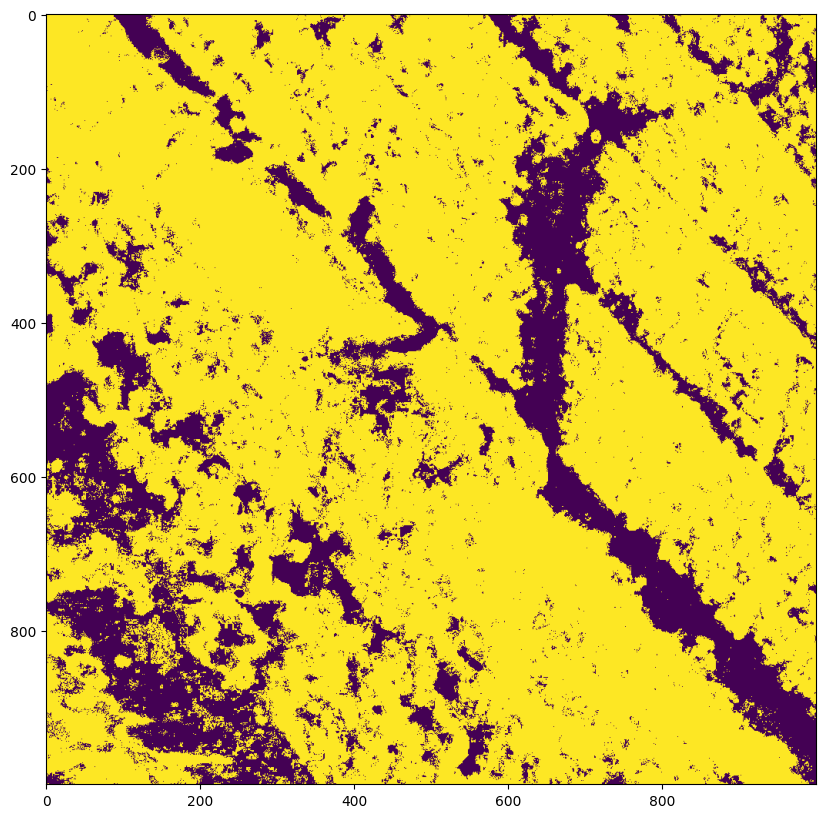

In [20]:
#Opening the final classified tiff:
import rasterio
with rasterio.open('Final_Classified_Result.tif') as src:
    classified_map = src.read(1)

print(classified_map.shape)
print(classified_map)

#Plotting the classified map:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(classified_map)
plt.show()